# 高次多項式ロジスティック回帰における暗黙の正則化と外挿

このノートブックでは、30次多項式という非常に表現力の高い特徴量を用いたロジスティック回帰を題材に、最急降下法が持つ驚くべき性質をハンズオンで確認します。
具体的には以下のトピックを実験を通じて学びます。

1. **暗黙の正則化（Implicit Regularization）とスペクトルバイアス**
2. **データのスケール変更による勾配降下法の挙動変化**
3. **特徴量の標準化による暗黙の正則化の破壊（過学習）**
4. **高次多項式特有の多重共線性（Multicollinearity）**
5. **多重共線性の相殺による未知領域（外挿）での予測の暴走**

## 1. セットアップとモデル定義


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import make_circles
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# グラフ描画用の設定
color_0 = 'tab:blue'
color_1 = 'tab:orange'
cmap_3d = mcolors.LinearSegmentedColormap.from_list('cmap_3d', [color_0, 'white', color_1])
cmap_heat = mcolors.LinearSegmentedColormap.from_list('cmap_heat', [color_0, color_1])
cmap_region = mcolors.ListedColormap(['#e0f7fa', '#ffebcc'])


In [10]:
import numpy as np
np.random.seed(42)  # 乱数シードを固定

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


class LinearInParameterLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.5, max_iter=10000, l2_lambda=0.0,
                 early_stopping_rounds=5, early_stopping_tolerance=1e-3, early_stopping_metric=['loss', 'misclassification_rate'][0],
                 verbose=False):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.l2_lambda = l2_lambda
        self.early_stopping_rounds = early_stopping_rounds
        self.early_stopping_tolerance = early_stopping_tolerance
        self.early_stopping_metric = early_stopping_metric
        self.verbose = verbose

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _objective(self, theta, X, y):
        """Compute training loss (cross-entropy + L2 regularization)."""
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        ce = -np.mean(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))
        reg = self.l2_lambda * np.sum(theta[1:] ** 2)
        return ce + reg

    def _loss_no_reg(self, theta, X, y):
        """Compute loss without L2 regularization."""
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        return -np.mean(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))

    def _gradient(self, theta, X, y):
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        grad = (1 / m) * X.T.dot(h - y)
        grad[1:] += 2 * self.l2_lambda * theta[1:]
        return grad

    def fit(self, X, y, X_val=None, y_val=None, X_test=None, y_test=None):
        """Train the model with gradient descent and early stopping."""
        self.theta_ = np.random.randn(X.shape[1]) * 0.01
        self.theta_init_ = self.theta_.copy()
        self.train_loss_, self.val_loss_, self.test_loss_ = [], [], []
        self.val_misclass_, self.test_misclass_ = [], []

        best_val_metric = np.inf
        no_improve = 0
        for i in range(self.max_iter):
            self.theta_ -= self.learning_rate * self._gradient(self.theta_, X, y)
            self.train_loss_.append(self._objective(self.theta_, X, y))

            if X_val is not None and y_val is not None:
                val_loss = self._loss_no_reg(self.theta_, X_val, y_val)
                self.val_loss_.append(val_loss)
                val_misclass = np.mean(self.predict(X_val) != y_val)
                self.val_misclass_.append(val_misclass)

                if self.early_stopping_metric == 'loss':
                    val_metric = val_loss
                elif self.early_stopping_metric == 'misclassification_rate':
                    val_metric = val_misclass

                if val_metric < best_val_metric - self.early_stopping_tolerance:
                    best_val_metric = val_metric
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping at iter {i}")
                    break

            if X_test is not None and y_test is not None:
                self.test_loss_.append(self._loss_no_reg(self.theta_, X_test, y_test))
                self.test_misclass_.append(np.mean(self.predict(X_test) != y_test))

        return self

    def predict(self, X):
        return (self._sigmoid(X.dot(self.theta_)) >= 0.5).astype(int)

    def predict_proba(self, X):
        """Return probability estimates for the input samples.
           Output shape: (n_samples, 2) where column 0 is P(class=0) and column 1 is P(class=1)."""
        probs = self._sigmoid(X.dot(self.theta_))
        return np.column_stack((1 - probs, probs))


# --- Define the palette ---
palette = {
    "Orange": "#FFA500",
    "Dark Orange": "#FF8C00",
    "Gray": "#808080",
    "Blue": "#0000FF",
    "Light Blue": "#ADD8E6",
    "Light Light Blue": "#E0FFFF",
    "Purple": "#800080"
}
region_cmap = ListedColormap(["#E0FFFF", "#FFF5E6"])

# --- Generate and preprocess data ---
X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# --- Hyperparameter Selection ---
polynomial_degree = 30
best_l2_lambda = min([0.001, 0.01, 0.1, 1.0], key=lambda reg:
    LinearInParameterLogisticRegression(l2_lambda=reg).fit(
        PolynomialFeatures(polynomial_degree).fit_transform(X_train), y_train,
        X_val=PolynomialFeatures(polynomial_degree).fit_transform(X_val), y_val=y_val
    ).val_loss_[-1]
)

# --- Feature Transformation ---
poly = PolynomialFeatures(degree=polynomial_degree, include_bias=False)
X_train_poly, X_val_poly, X_test_poly = [np.c_[np.ones(X_.shape[0]), poly.fit_transform(X_)]
                                         for X_ in [X_train, X_val, X_test]]

# --- Instantiate and train the model ---
model = LinearInParameterLogisticRegression(l2_lambda=best_l2_lambda, verbose=True)
model.fit(X_train_poly, y_train, X_val=X_val_poly, y_val=y_val, X_test=X_test_poly, y_test=y_test)


Early stopping at iter 289


,learning_rate,0.5
,max_iter,10000
,l2_lambda,0.001
,early_stopping_rounds,5
,early_stopping_tolerance,0.001
,early_stopping_metric,'loss'
,verbose,True


## データの生成と多項式特徴量
`make_circles` を用いて、同心円状のトイデータを生成します。さらに、非線形な決定境界を学習するために、入力特徴量を **30次多項式** に変換します。


In [11]:
X_train, y_train = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_test, y_test = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=123)

x_min, x_max = -1.6, 1.6
y_min, y_max = -1.6, 1.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

polynomial_degree = 30
poly = PolynomialFeatures(degree=polynomial_degree, include_bias=False)

# バイアス項を先頭に追加
X_train_poly = np.c_[np.ones(X_train.shape[0]), poly.fit_transform(X_train)]
grid_poly = np.c_[np.ones(grid.shape[0]), poly.transform(grid)]

print(f"元の特徴量数: {X_train.shape[1]}")
print(f"30次多項式変換後の特徴量数: {X_train_poly.shape[1] - 1} (バイアス除く)")


元の特徴量数: 2
30次多項式変換後の特徴量数: 495 (バイアス除く)


---
## 2. 実験1：暗黙の正則化とスペクトルバイアス (Implicit Regularization)

明示的な正則化（`l2_lambda=0.0`）を行わず、かつ**検証データを与えないことで早期終了（Early Stopping）を無効化**して、最急降下法の反復回数（`max_iter`）を5万回まで増やしてみます。

30次多項式は極めて表現力が高いため、通常であれば反復が進むにつれて過剰適合（過学習）し、決定境界がグニャグニャになるはずです。


反復回数(max_iter)の増加に伴う過学習の観察（標準化なし）:

========== 反復回数: 10 回 ==========


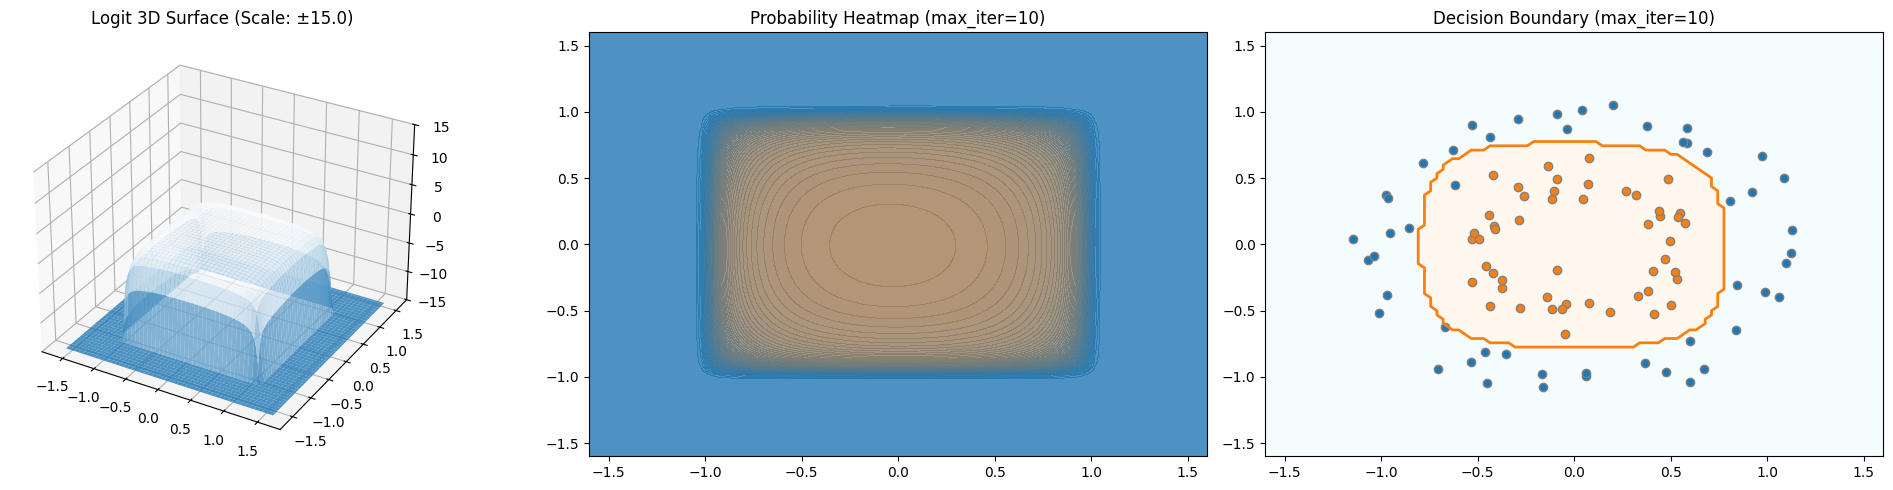

========== 反復回数: 100 回 ==========


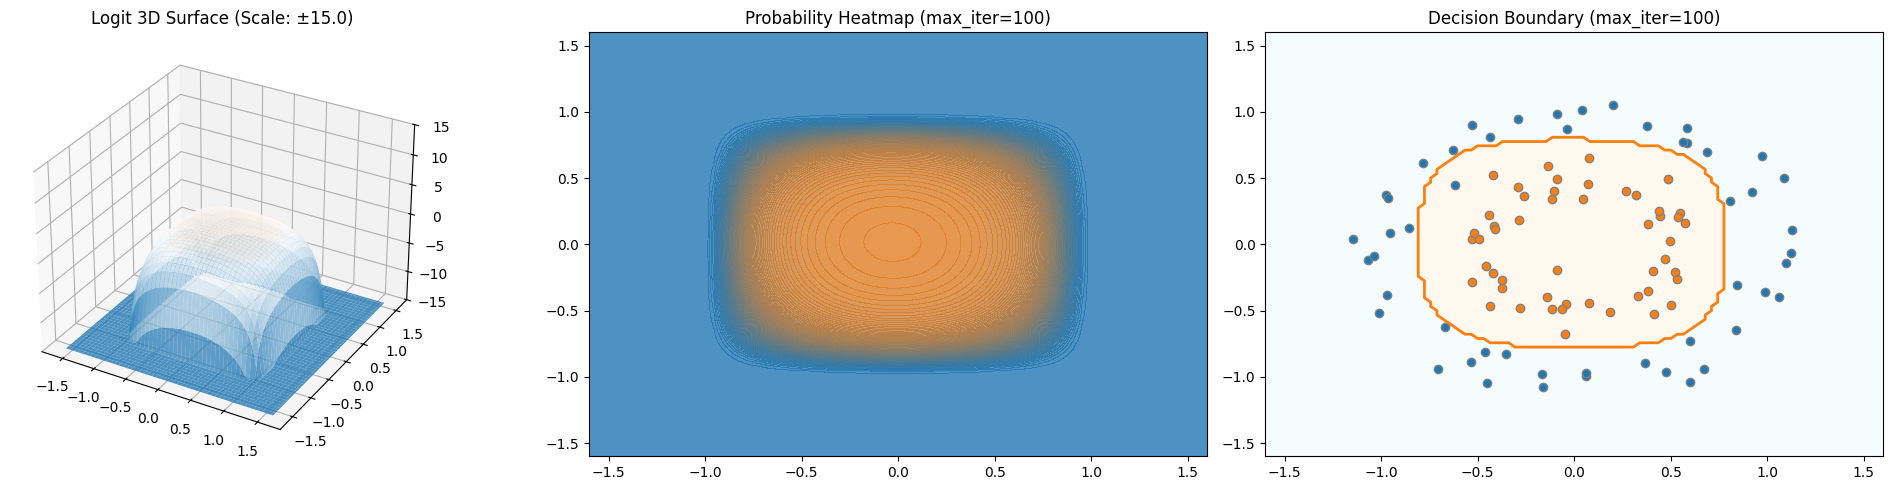

========== 反復回数: 1000 回 ==========


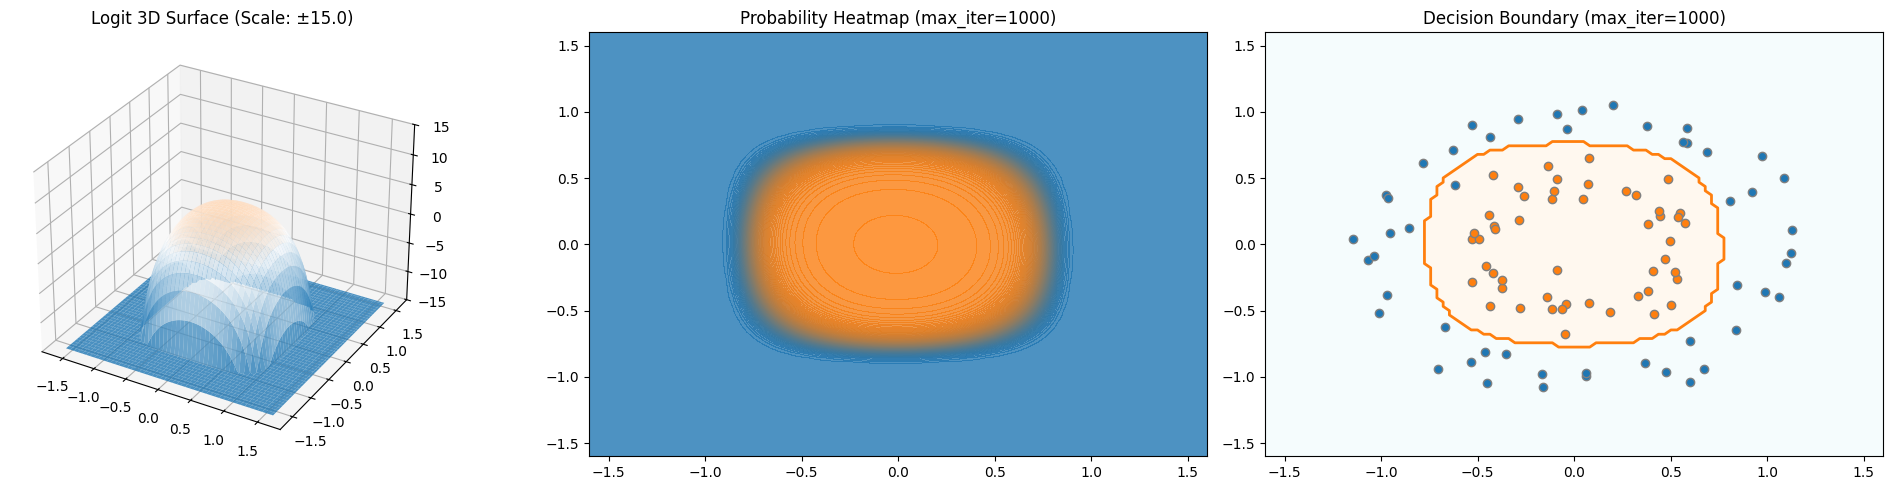

========== 反復回数: 10000 回 ==========


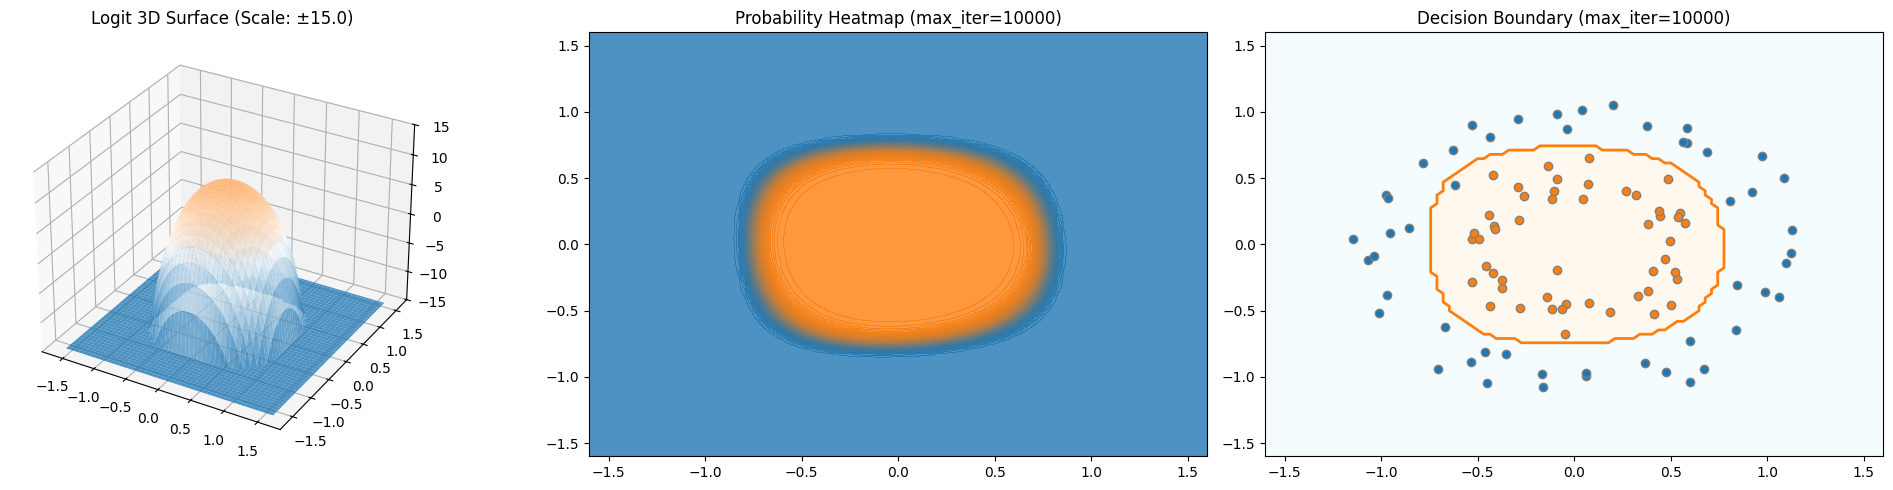

========== 反復回数: 50000 回 ==========


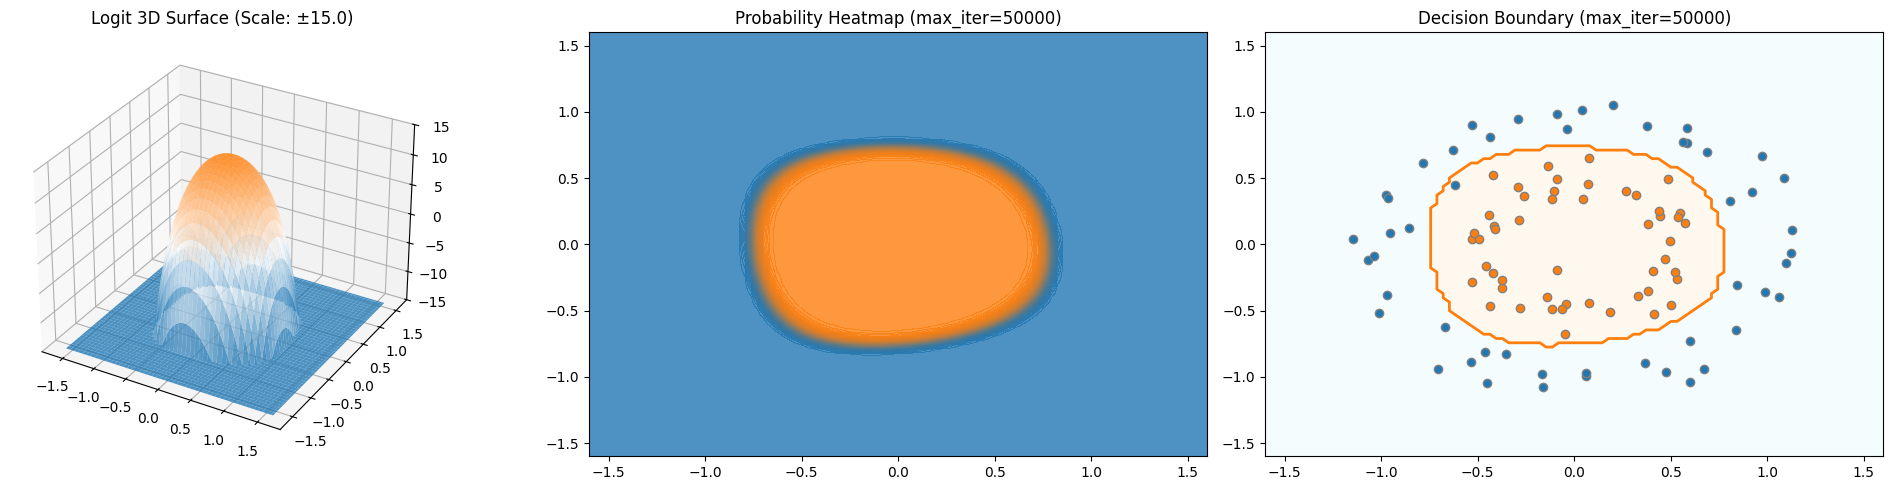

In [12]:
iters = [10, 100, 1000, 10000, 50000]

print("反復回数(max_iter)の増加に伴う過学習の観察（標準化なし）:\n")

for max_i in iters:
    np.random.seed(42)
    model_es = LinearInParameterLogisticRegression(l2_lambda=0.0, learning_rate=0.5, max_iter=max_i, verbose=False)
    model_es.fit(X_train_poly, y_train)

    print(f"========== 反復回数: {max_i} 回 ==========")
    logits = grid_poly.dot(model_es.theta_).reshape(xx.shape)
    output_probs = model_es._sigmoid(logits).reshape(xx.shape)

    fig = plt.figure(figsize=(20, 5))
    ax = fig.add_subplot(1, 3, 1, projection='3d')
    vmax = min(max(np.max(np.abs(logits)), 1e-3), 15)
    logits_clipped = np.clip(logits, -vmax, vmax)
    surf = ax.plot_surface(xx, yy, logits_clipped, cmap=cmap_3d, vmin=-vmax, vmax=vmax, alpha=0.8)
    ax.set_zlim(-vmax, vmax)
    ax.set_title(f"Logit 3D Surface (Scale: ±{vmax:.1f})")

    plt.subplot(1, 3, 2)
    plt.contourf(xx, yy, output_probs, levels=np.linspace(0, 1, 100), cmap=cmap_heat, vmin=0, vmax=1, alpha=0.8)
    plt.title(f"Probability Heatmap (max_iter={max_i})")

    Z = (output_probs >= 0.5)
    plt.subplot(1, 3, 3)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_region)
    plt.contour(xx, yy, Z, levels=[0.5], colors=color_1, linewidths=2)
    for cls in [0, 1]:
        plt.scatter(X_test[y_test == cls, 0], X_test[y_test == cls, 1], c=color_0 if cls==0 else color_1, edgecolor='gray')
    plt.title(f"Decision Boundary (max_iter={max_i})")
    plt.tight_layout()
    plt.show()


**なぜ過学習しないのか？（スペクトルバイアス）**
入力データのスケールが $[-1, 1]$ 程度であるため、それを30乗した高次特徴量の値は極端にゼロに近く（例：$0.5^{30} \approx 10^{-9}$）なります。最急降下法の勾配は特徴量の大きさに比例するため、高次特徴量は全く学習が進まず、初期値のまま放置されます。これが結果的に強力な「過学習防止機構（暗黙の正則化）」として働いています。


---
## 3. 実験2：データのスケール変更による挙動の変化 (Effect of Data Scaling)

上の事実を確認するため、元のデータ $X$ を **2倍に拡大** したデータと、**0.1倍に縮小** したデータを作って、学習の進み方がどう変わるか実験します。
（注：ここでは高次特徴量の勾配が爆発するため、発散を防ぐ目的で学習率 `learning_rate` を大幅に下げています。）



 元データのスケール: 1.5倍 (学習率: 0.01, L2正則化: 0.0)

--- スケール: 1.5倍 | 反復回数: 10 回 ---


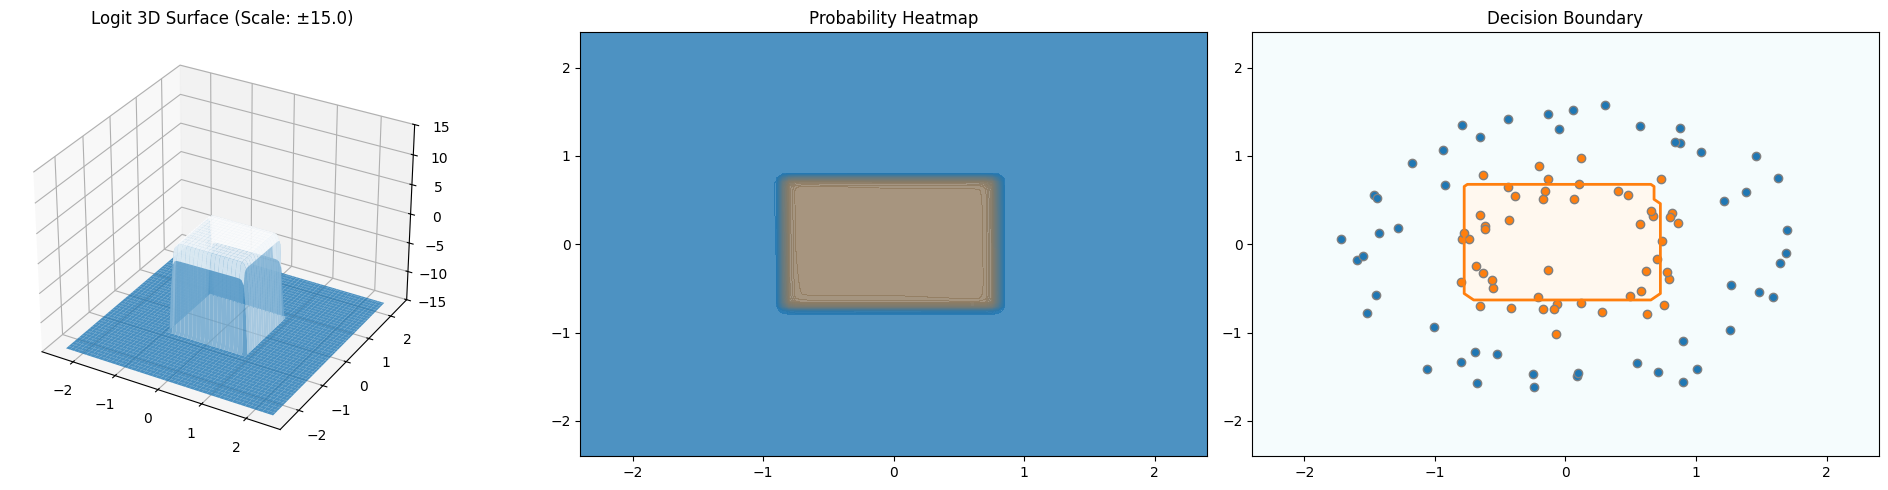


--- スケール: 1.5倍 | 反復回数: 100 回 ---


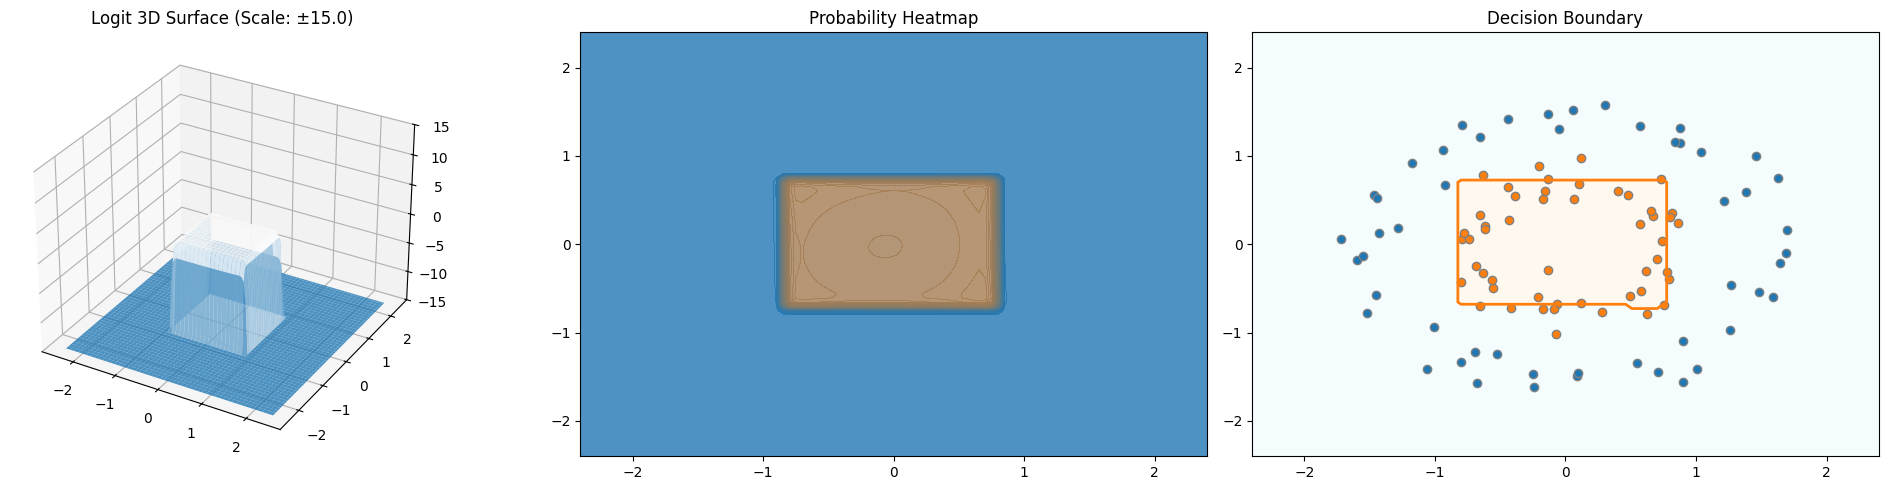


--- スケール: 1.5倍 | 反復回数: 1000 回 ---


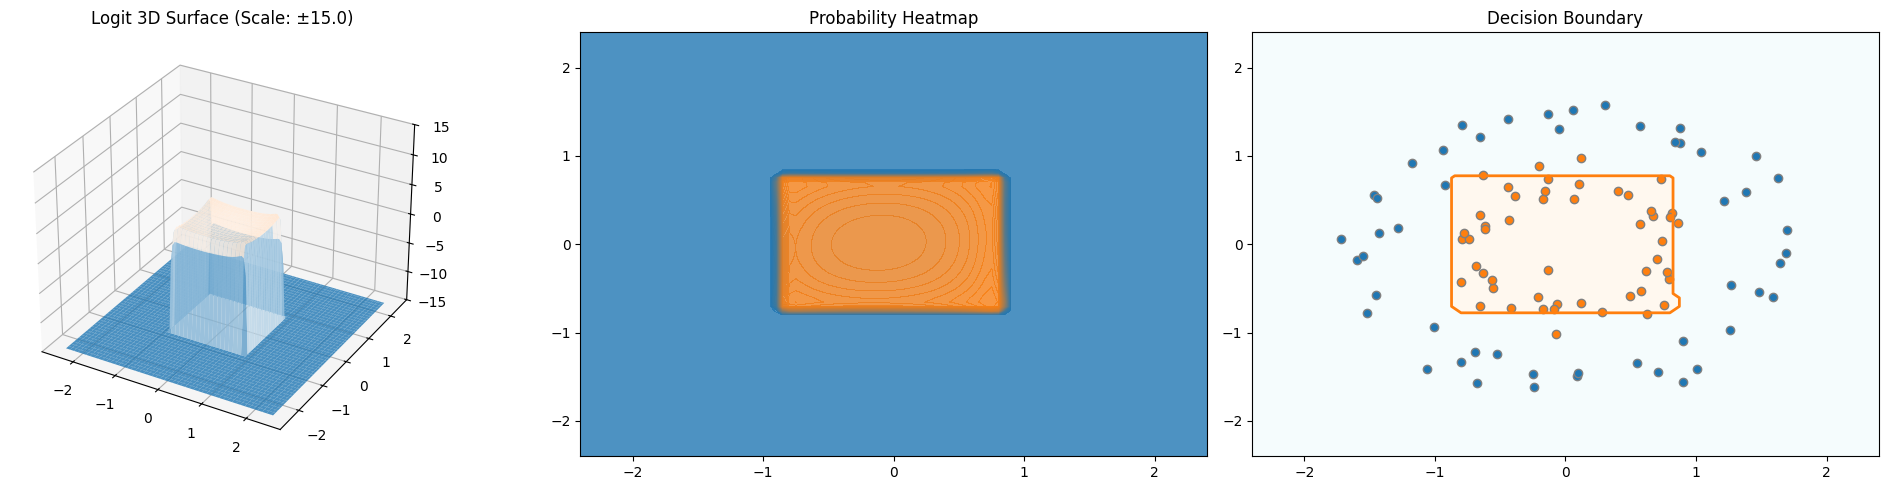


--- スケール: 1.5倍 | 反復回数: 10000 回 ---


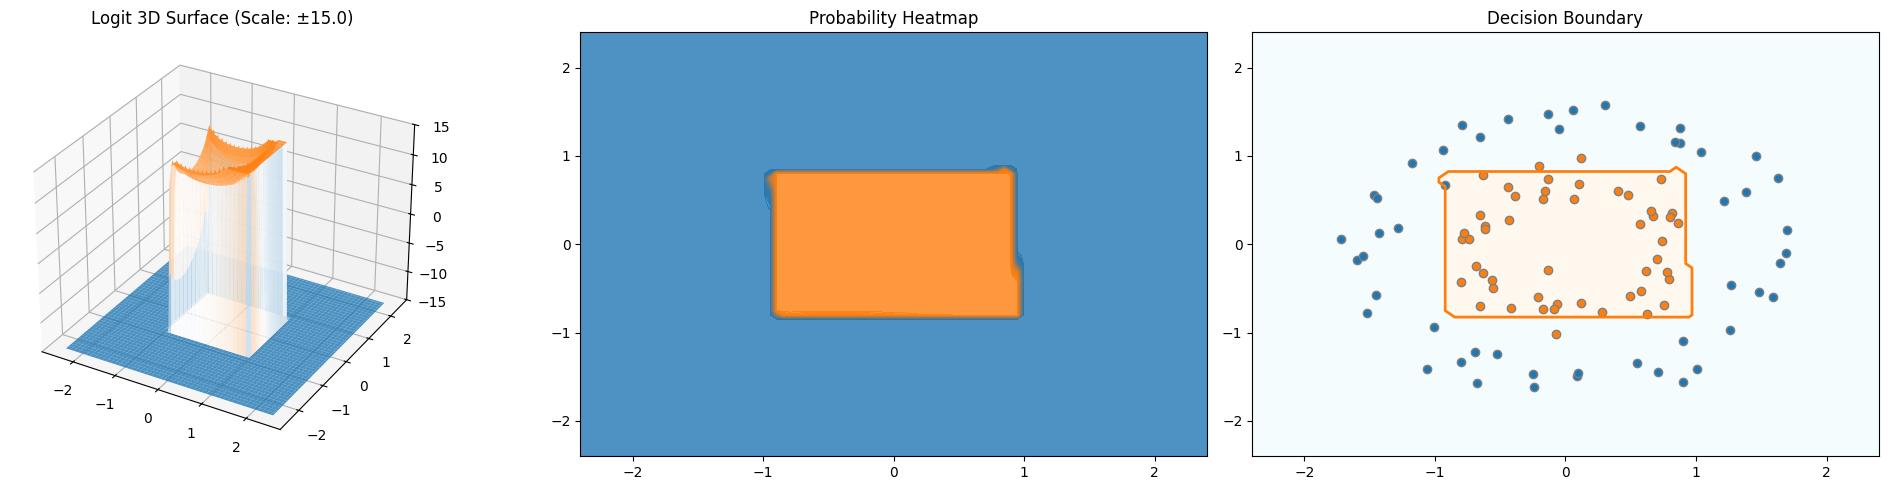


--- スケール: 1.5倍 | 反復回数: 50000 回 ---


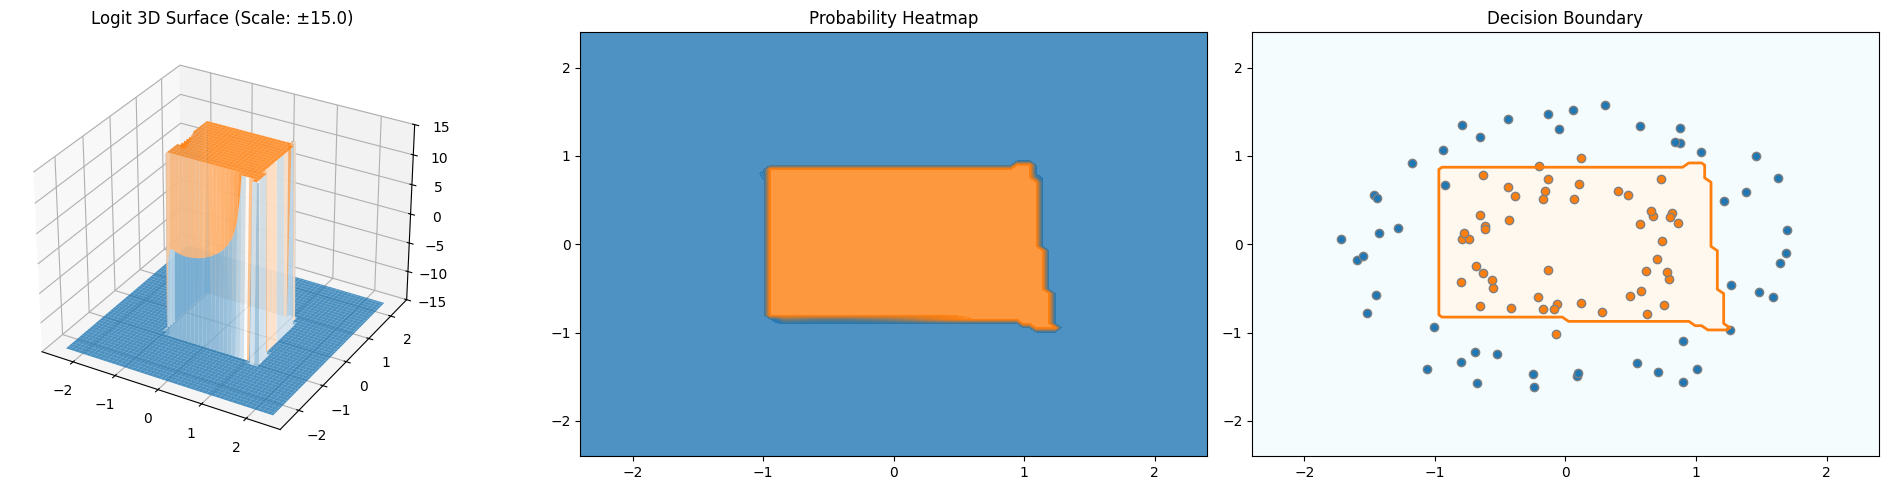


--- スケール: 1.5倍 | 反復回数: 100000 回 ---


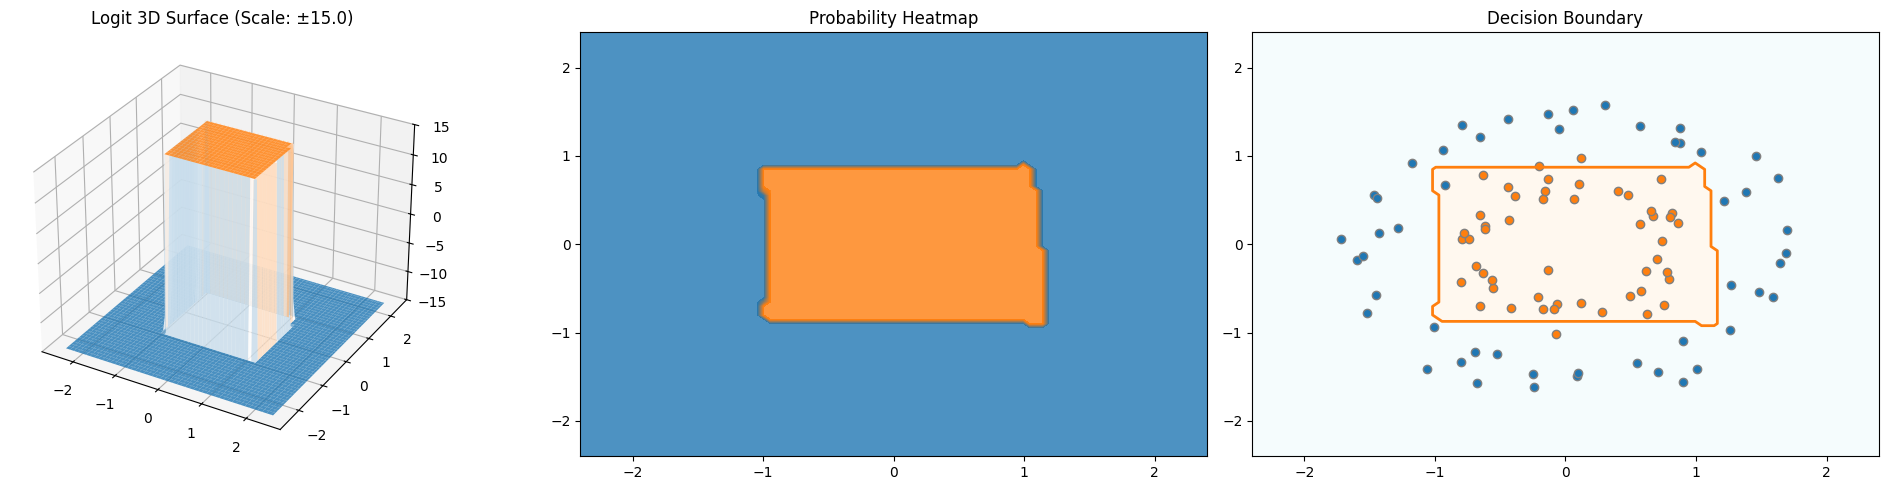


 元データのスケール: 1.5倍 (学習率: 0.01, L2正則化: 0.05)

--- スケール: 1.5倍 | 反復回数: 10 回 ---


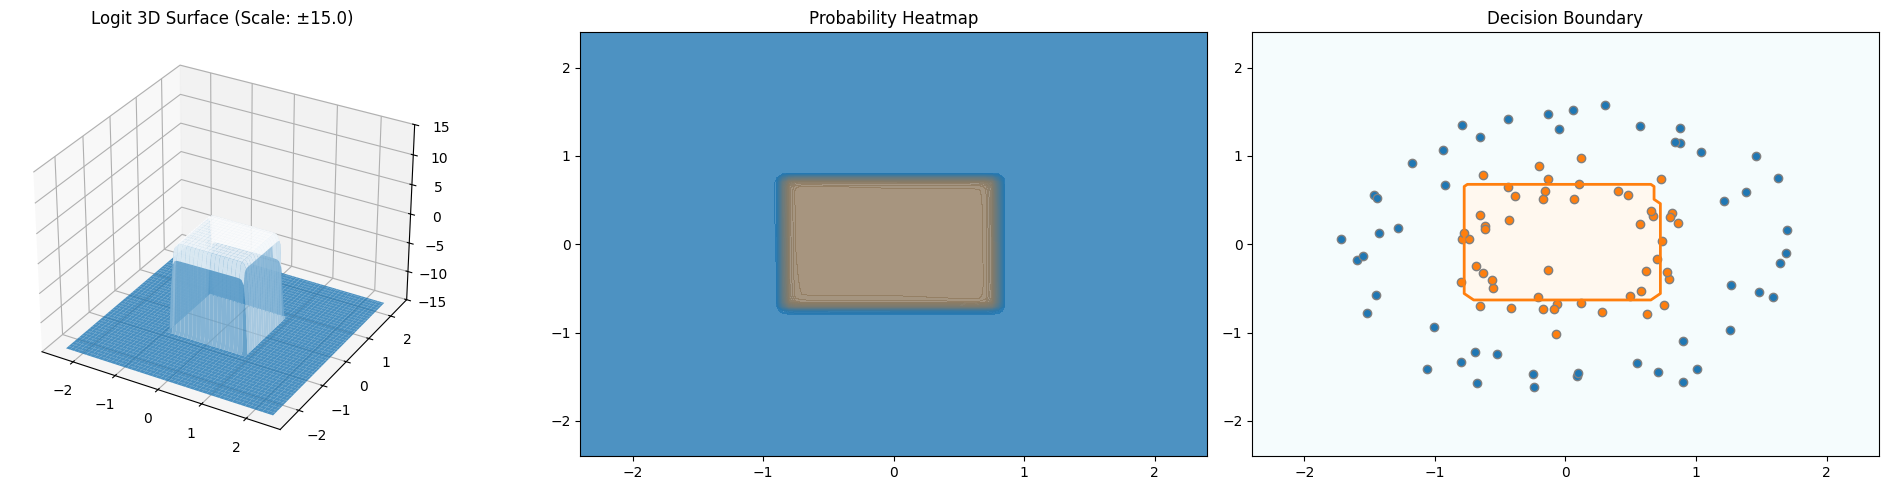


--- スケール: 1.5倍 | 反復回数: 100 回 ---


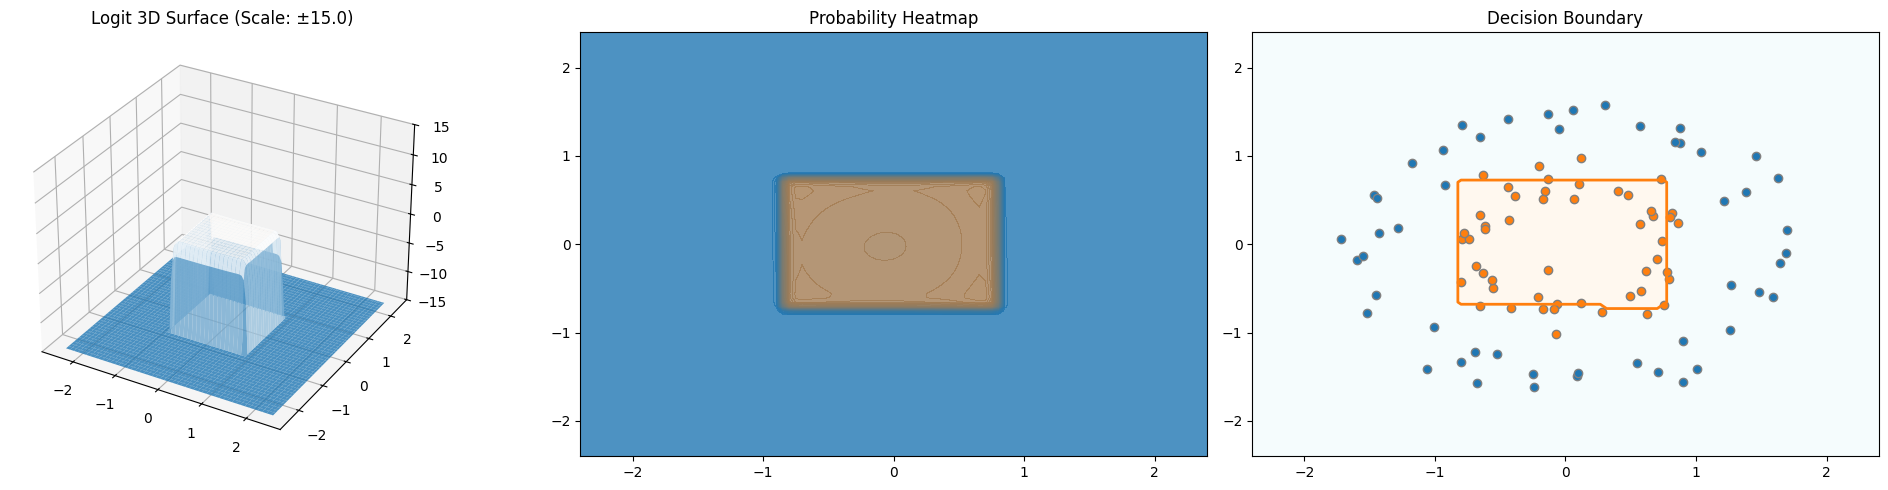


--- スケール: 1.5倍 | 反復回数: 1000 回 ---


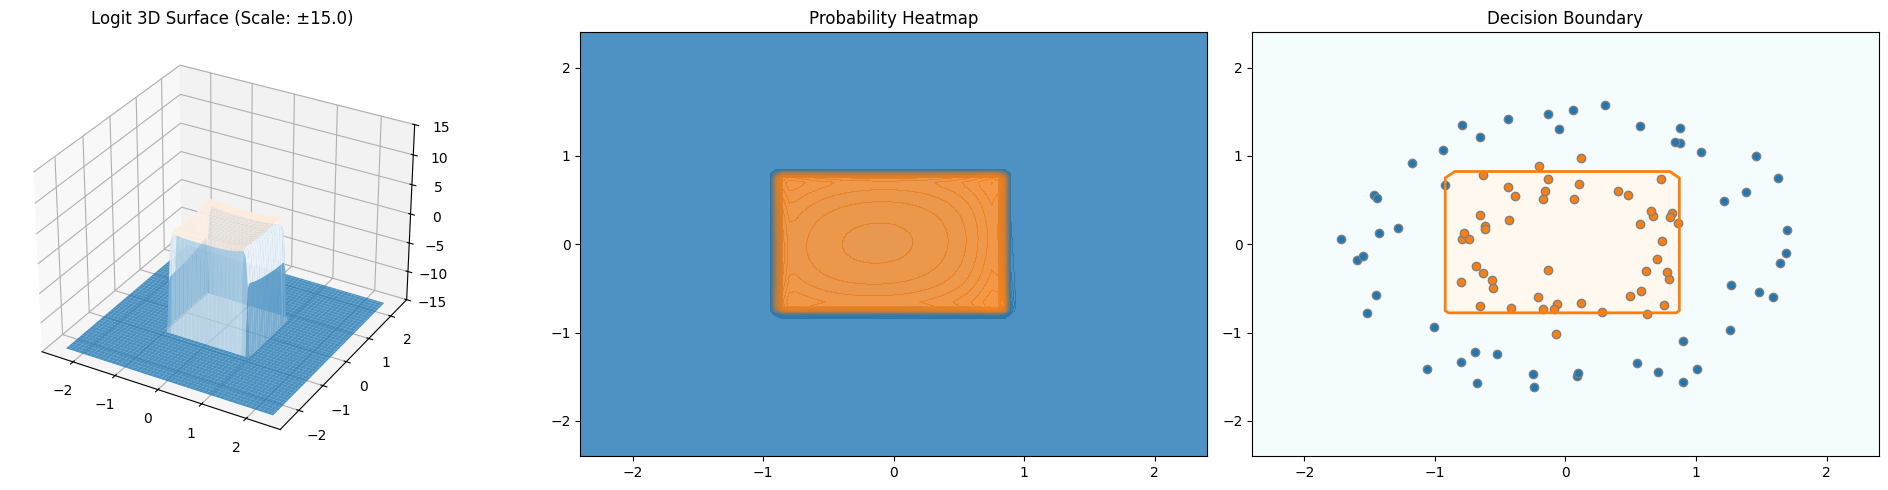


--- スケール: 1.5倍 | 反復回数: 10000 回 ---


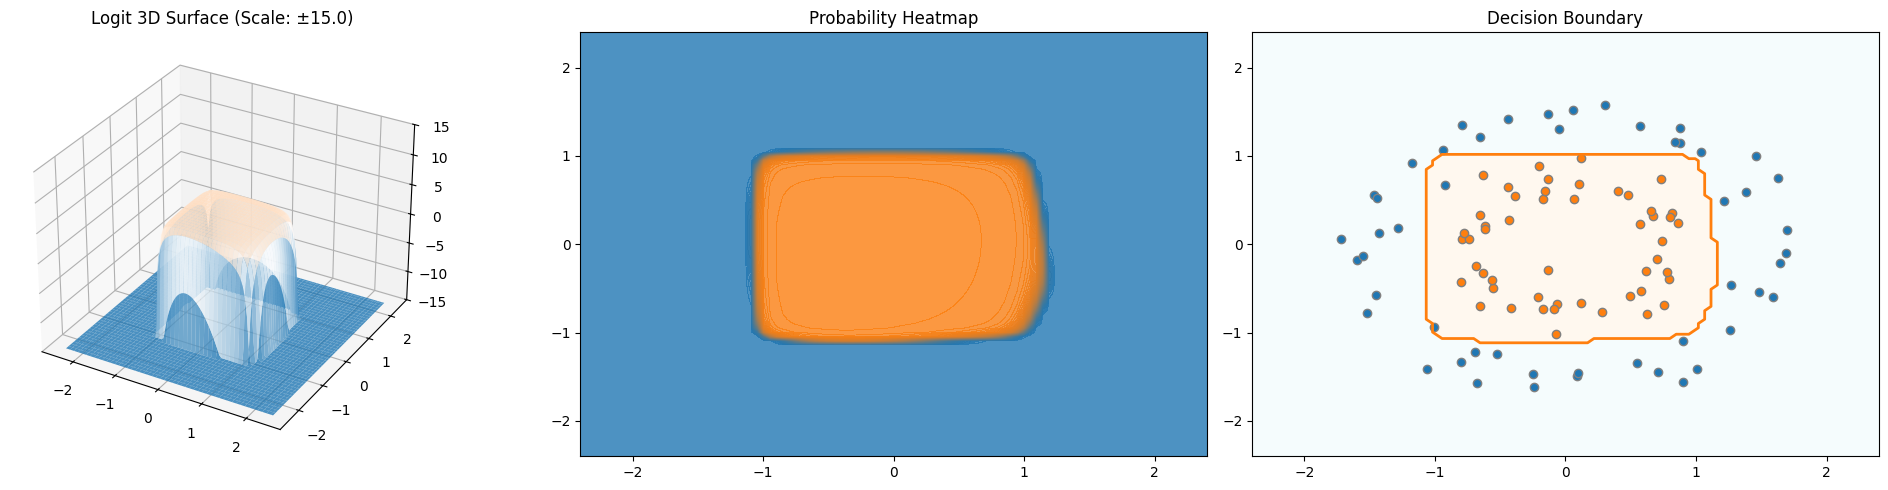


--- スケール: 1.5倍 | 反復回数: 50000 回 ---


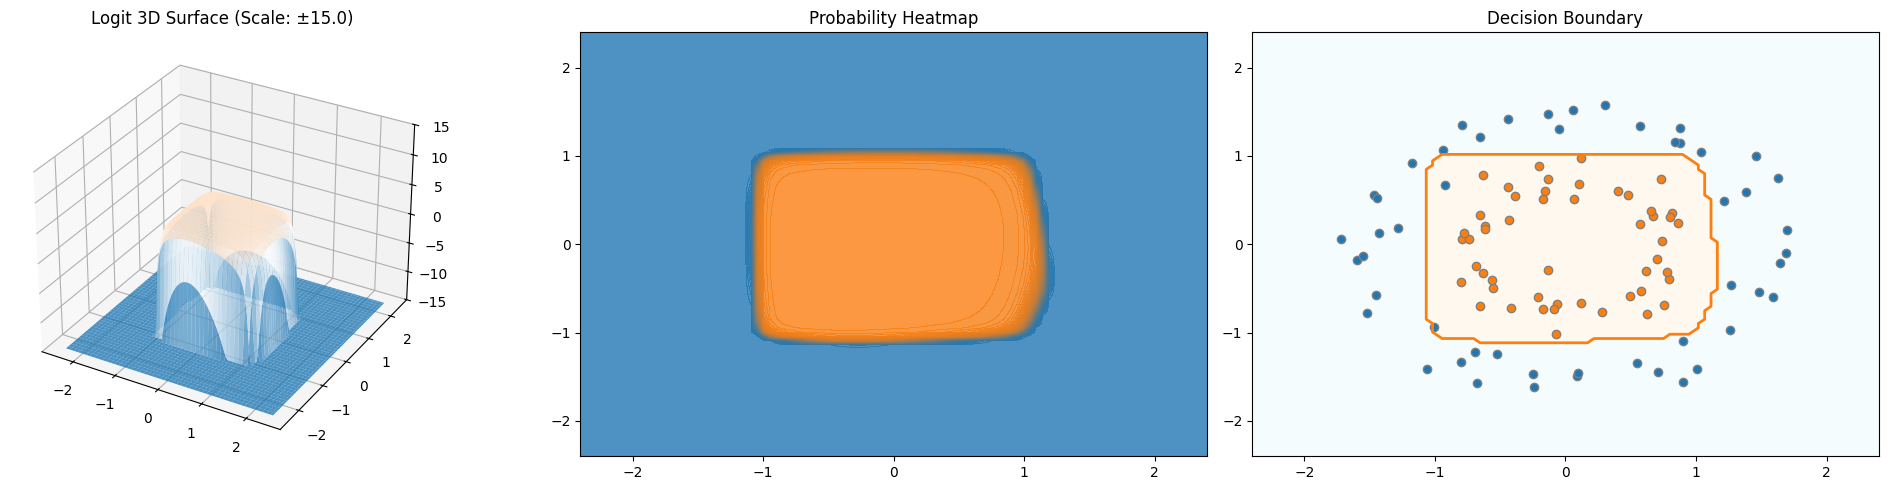


--- スケール: 1.5倍 | 反復回数: 100000 回 ---


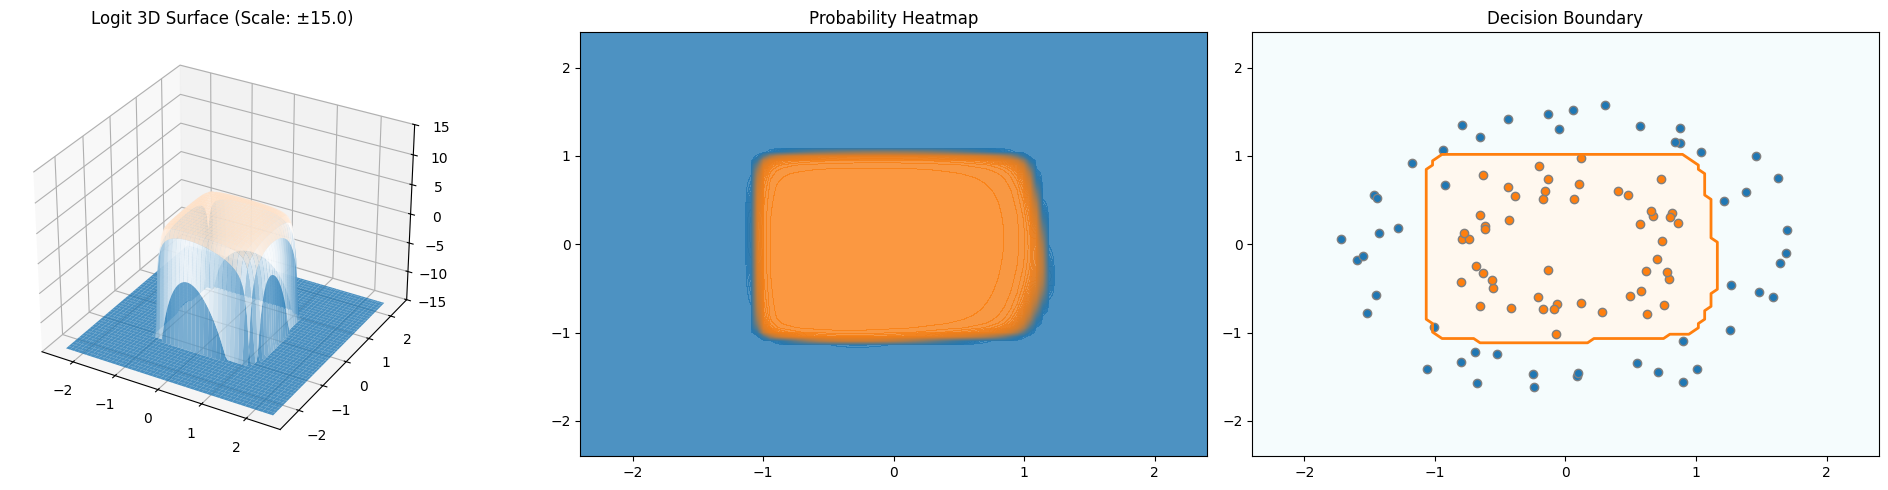


 元データのスケール: 0.1倍 (学習率: 0.5, L2正則化: 0.0)

--- スケール: 0.1倍 | 反復回数: 10 回 ---


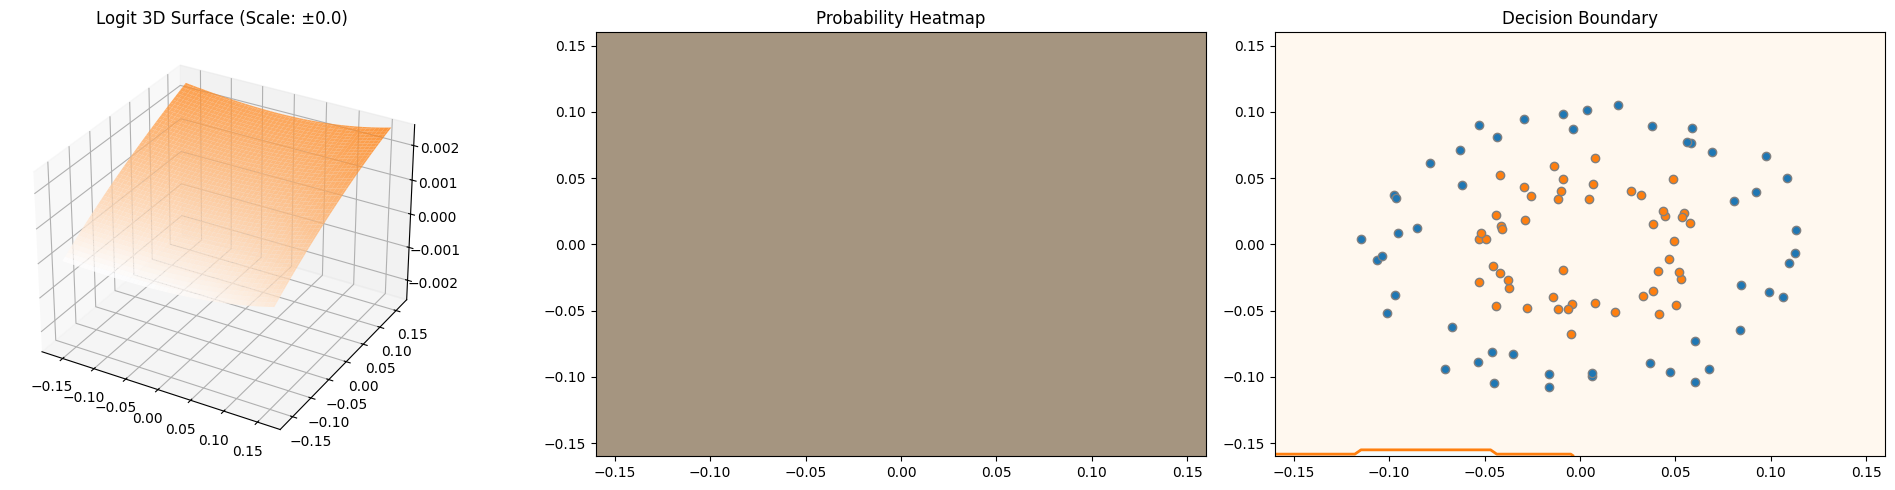


--- スケール: 0.1倍 | 反復回数: 100 回 ---


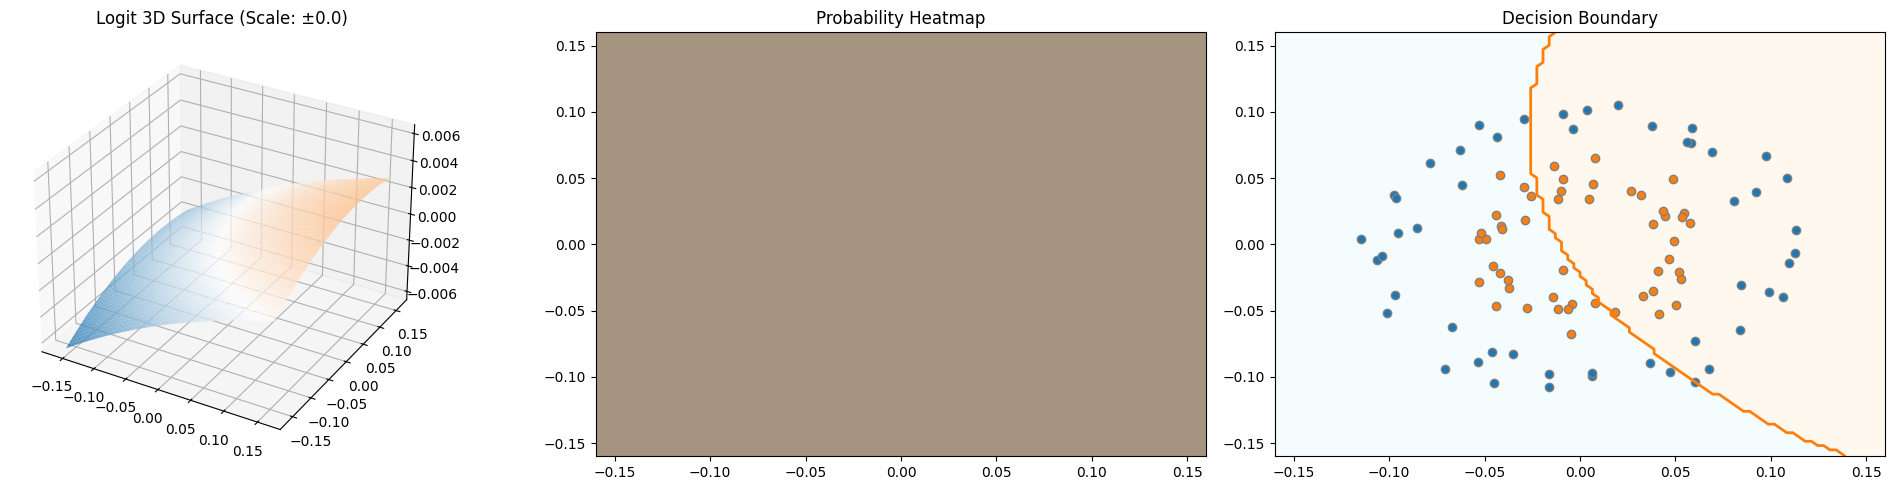


--- スケール: 0.1倍 | 反復回数: 1000 回 ---


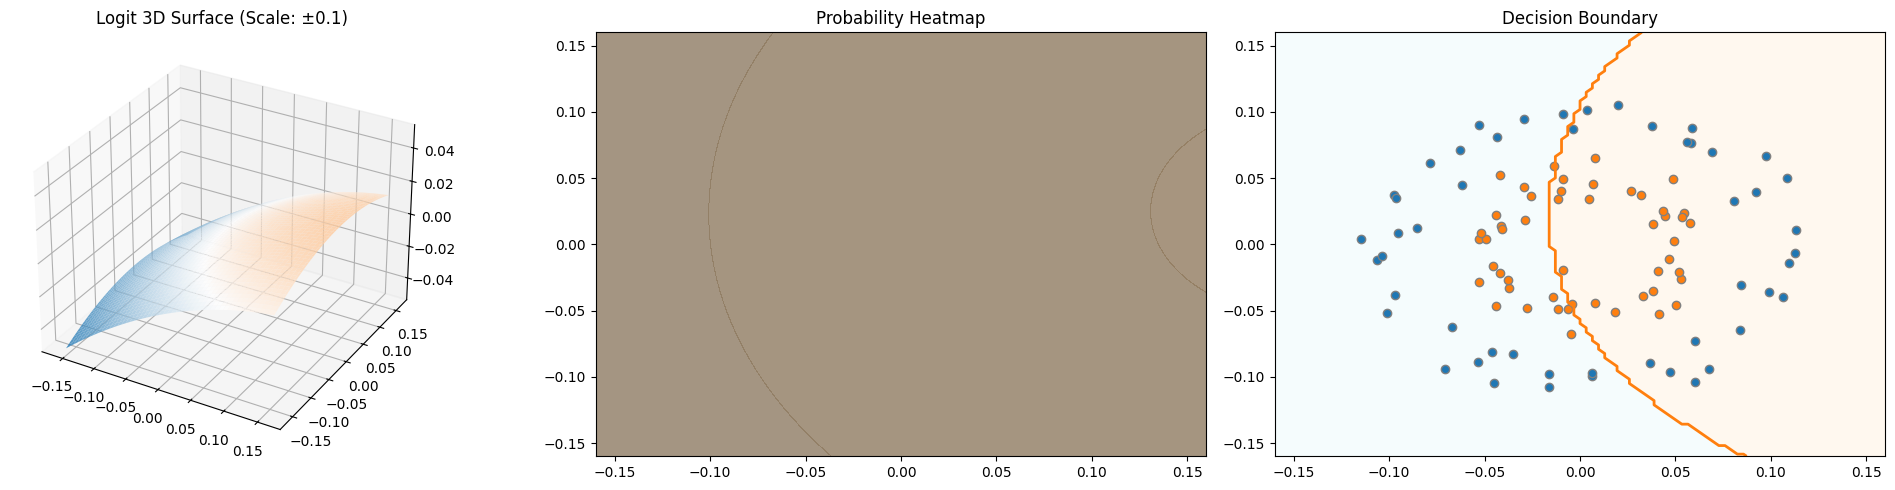


--- スケール: 0.1倍 | 反復回数: 10000 回 ---


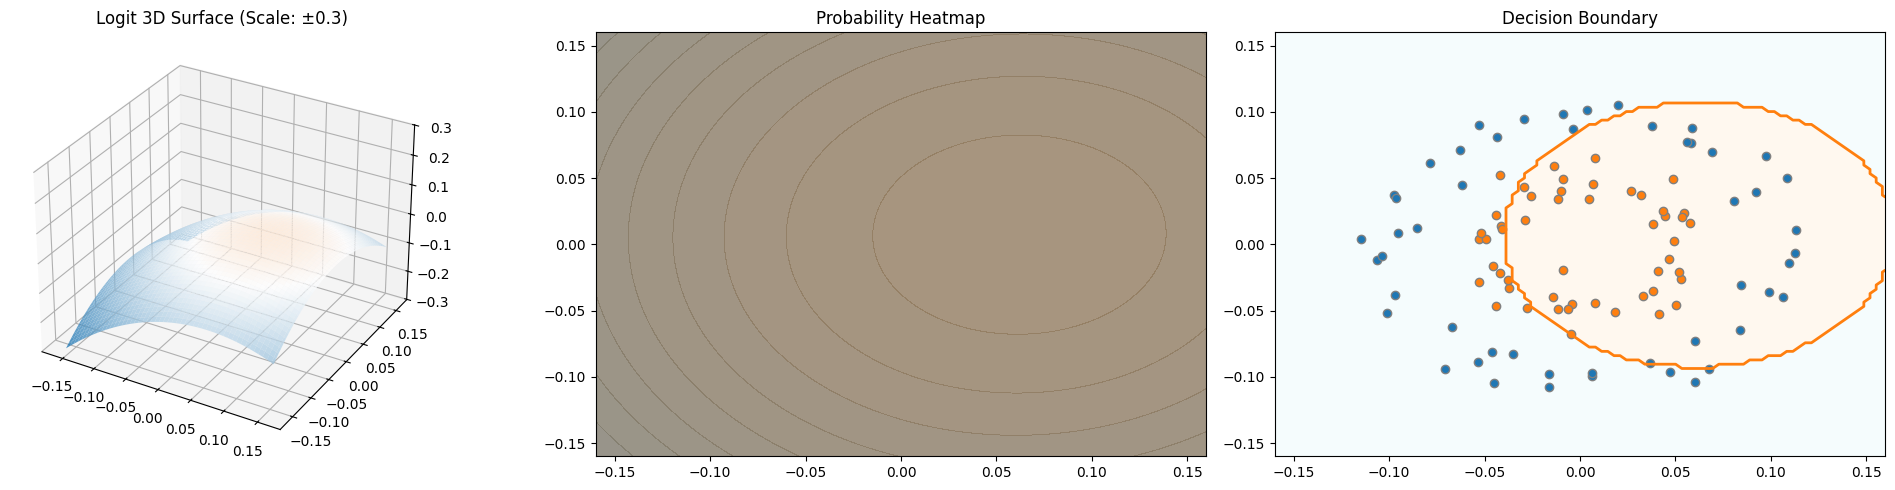


--- スケール: 0.1倍 | 反復回数: 50000 回 ---


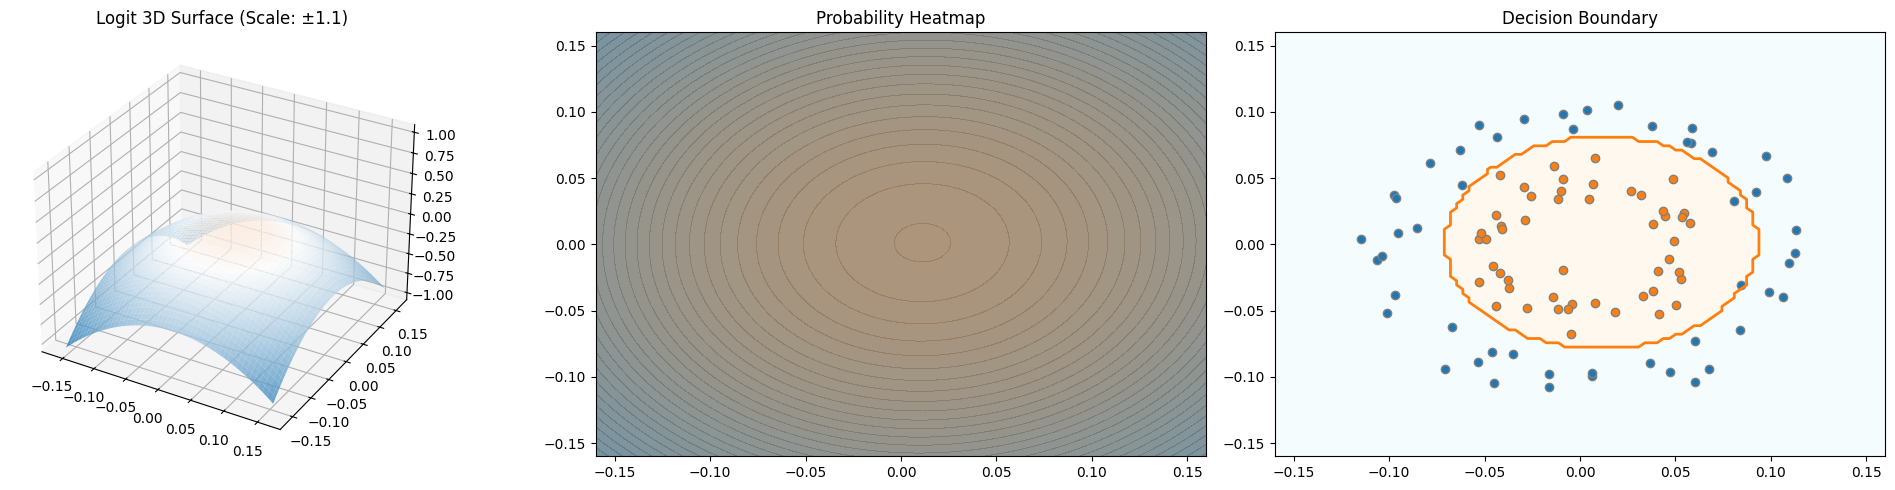


--- スケール: 0.1倍 | 反復回数: 100000 回 ---


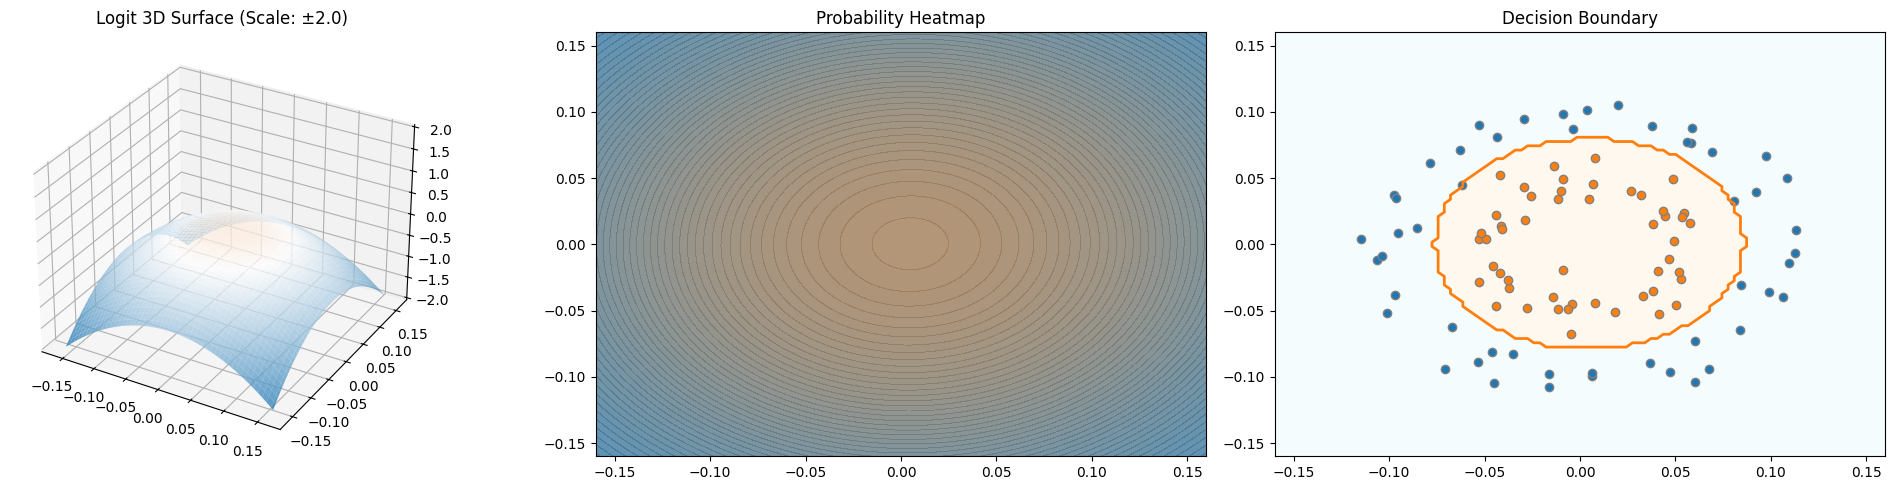

In [24]:
# スケール(scale)、学習率(lr)、L2正則化(l2_lambda)の組み合わせを自由に設定できるようにリスト化しています
# ぜひ値を変更して、どのような挙動になるか実験してみてください
experiments = [
    {'scale': 1.5, 'lr': 1e-2, 'l2_lambda': 0.0},
    {'scale': 1.5, 'lr': 1e-2, 'l2_lambda': 0.05},
    {'scale': 0.1, 'lr': 0.5, 'l2_lambda': 0.0}
]
iters_exp2 = [10, 100, 1000, 10000, 50000, 100000]

for exp in experiments:
    scale = exp['scale']
    lr = exp['lr']
    l2_lambda = exp.get('l2_lambda', 0.0)
    print(f"\n{'='*30}\n 元データのスケール: {scale}倍 (学習率: {lr}, L2正則化: {l2_lambda})\n{'='*30}")

    # データのスケール変更と多項式特徴量の生成
    X_scaled_raw = X_train * scale
    X_scaled_poly = np.c_[np.ones(X_scaled_raw.shape[0]), poly.fit_transform(X_scaled_raw)]

    grid_scaled_raw = grid * scale
    grid_scaled_poly = np.c_[np.ones(grid_scaled_raw.shape[0]), poly.transform(grid_scaled_raw)]
    X_test_scaled_raw = X_test * scale

    # グリッドのプロット用座標もスケールに合わせる
    xx_scaled = xx * scale
    yy_scaled = yy * scale

    for max_i in iters_exp2:
        np.random.seed(42)
        model_scaled = LinearInParameterLogisticRegression(l2_lambda=l2_lambda, learning_rate=lr, max_iter=max_i, verbose=False)
        model_scaled.fit(X_scaled_poly, y_train)

        print(f"\n--- スケール: {scale}倍 | 反復回数: {max_i} 回 ---")
        logits = grid_scaled_poly.dot(model_scaled.theta_).reshape(xx_scaled.shape)
        output_probs = model_scaled._sigmoid(grid_scaled_poly.dot(model_scaled.theta_)).reshape(xx_scaled.shape)

        fig = plt.figure(figsize=(20, 5))

        # 1. 3D Plot
        ax = fig.add_subplot(1, 3, 1, projection='3d')
        vmax = min(max(np.max(np.abs(logits)), 1e-3), 15)
        logits_clipped = np.clip(logits, -vmax, vmax)
        surf = ax.plot_surface(xx_scaled, yy_scaled, logits_clipped, cmap=cmap_3d, vmin=-vmax, vmax=vmax, alpha=0.8)
        ax.set_zlim(-vmax, vmax)
        ax.set_title(f"Logit 3D Surface (Scale: ±{vmax:.1f})")

        # 2. Probability Heatmap
        plt.subplot(1, 3, 2)
        plt.contourf(xx_scaled, yy_scaled, output_probs, levels=np.linspace(0, 1, 100), cmap=cmap_heat, vmin=0, vmax=1, alpha=0.8)
        plt.title(f"Probability Heatmap")

        # 3. Decision Boundary
        Z = (output_probs >= 0.5)
        plt.subplot(1, 3, 3)
        plt.contourf(xx_scaled, yy_scaled, Z, alpha=0.3, cmap=cmap_region)
        plt.contour(xx_scaled, yy_scaled, Z, levels=[0.5], colors=color_1, linewidths=2)
        for cls in [0, 1]:
            plt.scatter(X_test_scaled_raw[y_test == cls, 0], X_test_scaled_raw[y_test == cls, 1], c=color_0 if cls==0 else color_1, edgecolor='gray')
        plt.title(f"Decision Boundary")
        plt.tight_layout()
        plt.show()


2倍のスケールでは、高次項（$2^{30} \approx 10^9$）の影響が強すぎて、超低学習率でも決定境界が極端に歪む（過学習する）か、最適化が難しくなります。0.1倍では高次項が完全に無視され、滑らかな円（低次項のみの学習）になります。


---
## 4. 実験3：特徴量の標準化と過学習の暴走 (Standardization & Overfitting)

次に、`StandardScaler` を用いて、すべての特徴量の分散を 1 に標準化します。
これにより、高次特徴量にも平等に学習が進むようになり、「暗黙の正則化」が破壊されます。反復回数に伴って過学習がどう暴走するかを観察します。


反復回数(max_iter)の増加に伴う過学習の観察（標準化あり）:

========== 反復回数: 10 回 ==========


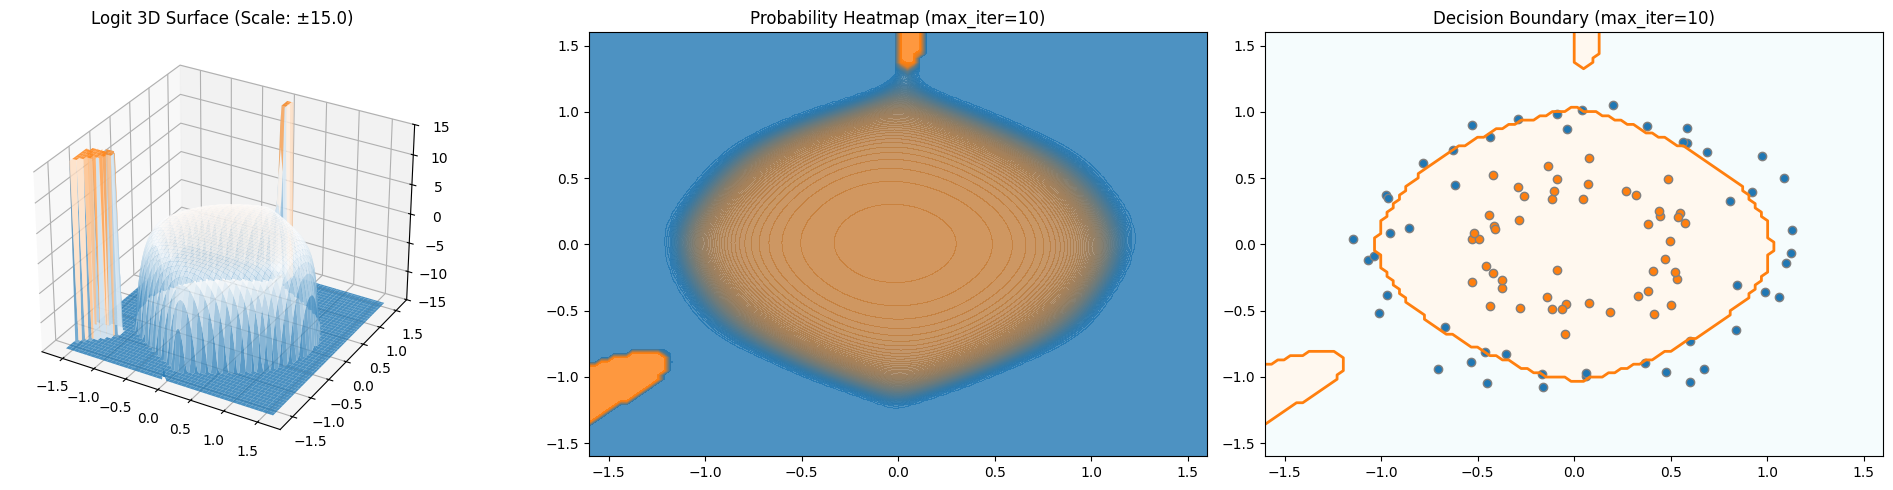

========== 反復回数: 100 回 ==========


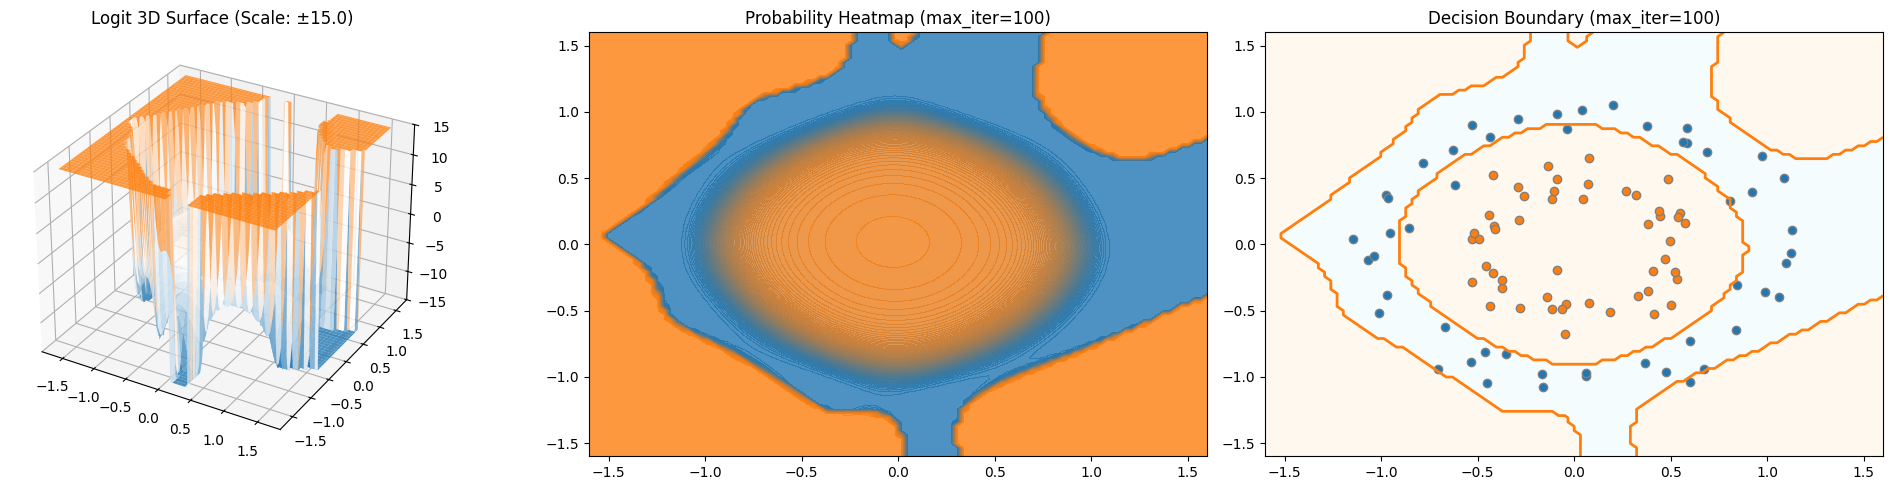

========== 反復回数: 1000 回 ==========


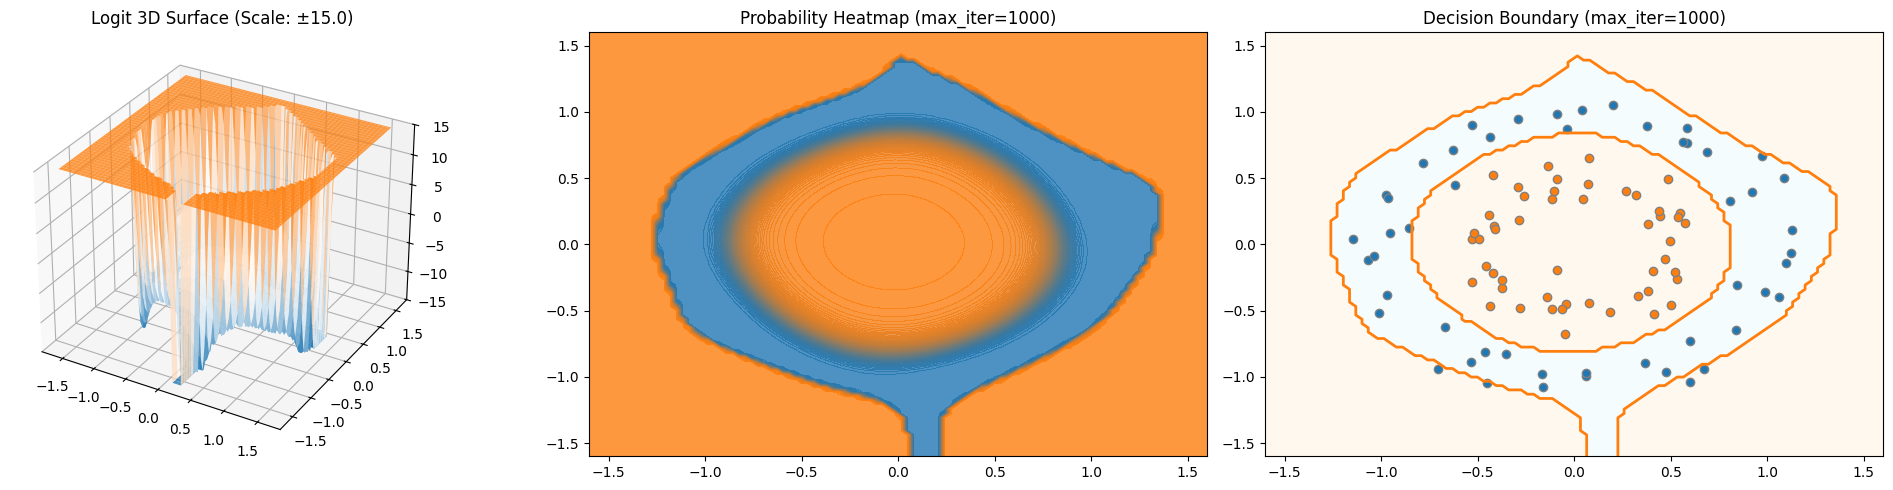

========== 反復回数: 10000 回 ==========


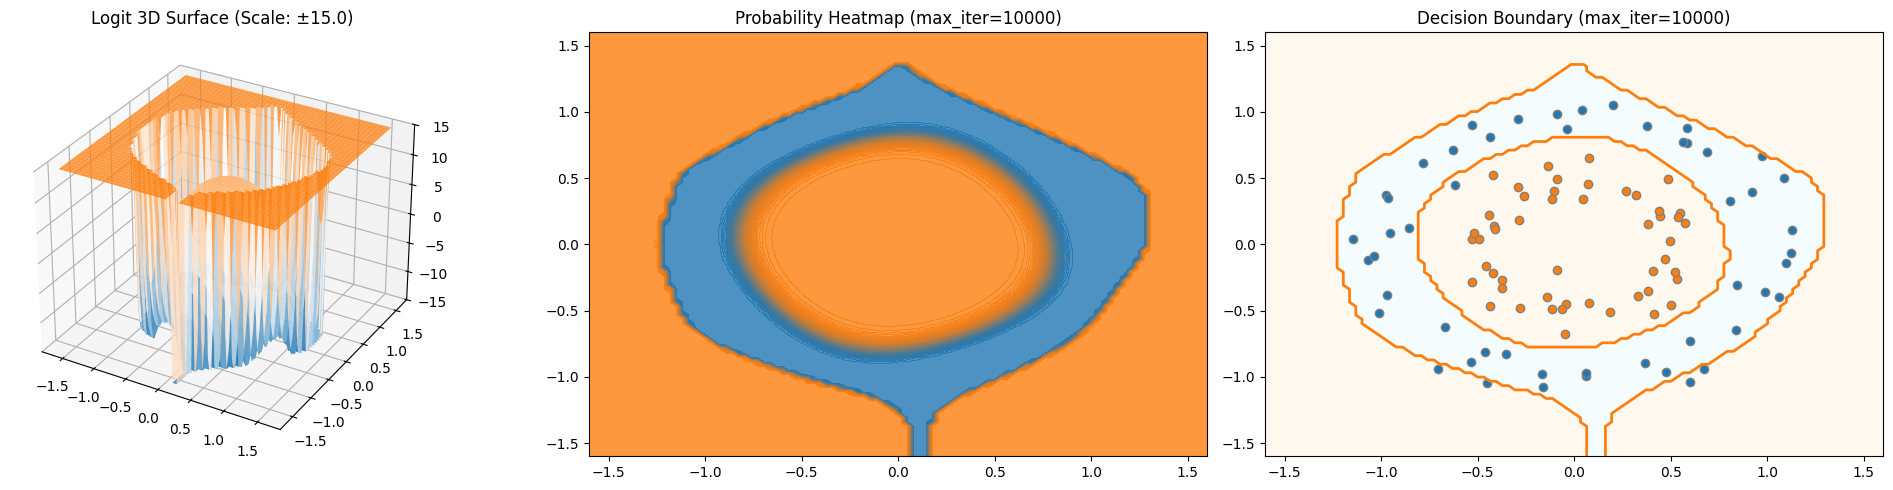

========== 反復回数: 50000 回 ==========


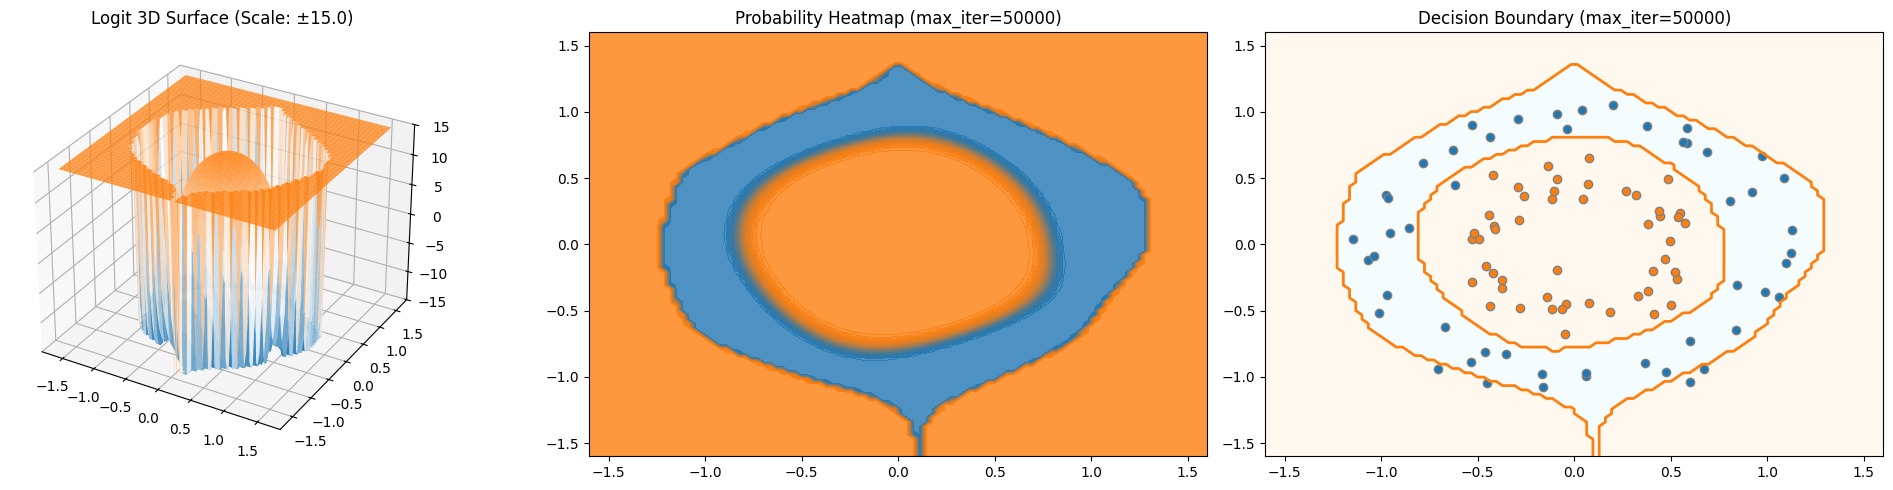

In [14]:
scaler = StandardScaler()
X_train_poly_scaled = X_train_poly.copy()
X_train_poly_scaled[:, 1:] = scaler.fit_transform(X_train_poly[:, 1:])

grid_poly_scaled = grid_poly.copy()
grid_poly_scaled[:, 1:] = scaler.transform(grid_poly[:, 1:])

iters_scaled = [10, 100, 1000, 10000, 50000]

print("反復回数(max_iter)の増加に伴う過学習の観察（標準化あり）:\n")

for max_i in iters_scaled:
    np.random.seed(42)
    model_es_scaled = LinearInParameterLogisticRegression(l2_lambda=0.0, learning_rate=0.05, max_iter=max_i, verbose=False)
    model_es_scaled.fit(X_train_poly_scaled, y_train)

    print(f"========== 反復回数: {max_i} 回 ==========")
    logits = grid_poly_scaled.dot(model_es_scaled.theta_).reshape(xx.shape)
    output_probs = model_es_scaled._sigmoid(logits).reshape(xx.shape)

    fig = plt.figure(figsize=(20, 5))
    ax = fig.add_subplot(1, 3, 1, projection='3d')
    vmax = min(max(np.max(np.abs(logits)), 1e-3), 15)
    logits_clipped = np.clip(logits, -vmax, vmax)
    surf = ax.plot_surface(xx, yy, logits_clipped, cmap=cmap_3d, vmin=-vmax, vmax=vmax, alpha=0.8)
    ax.set_zlim(-vmax, vmax)
    ax.set_title(f"Logit 3D Surface (Scale: ±{vmax:.1f})")

    plt.subplot(1, 3, 2)
    plt.contourf(xx, yy, output_probs, levels=np.linspace(0, 1, 100), cmap=cmap_heat, vmin=0, vmax=1, alpha=0.8)
    plt.title(f"Probability Heatmap (max_iter={max_i})")

    Z = (output_probs >= 0.5)
    plt.subplot(1, 3, 3)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_region)
    plt.contour(xx, yy, Z, levels=[0.5], colors=color_1, linewidths=2)
    for cls in [0, 1]:
        plt.scatter(X_test[y_test == cls, 0], X_test[y_test == cls, 1], c=color_0 if cls==0 else color_1, edgecolor='gray')
    plt.title(f"Decision Boundary (max_iter={max_i})")
    plt.tight_layout()
    plt.show()


---
## 5. 実験4：値の範囲と多重共線性 (Multicollinearity)

なぜ反復を5万回も回すと、未知の領域（データの外側の四隅）が不自然に反り返ってクラス1（オレンジ）に誤分類されるのでしょうか？
その原因は、高次多項式特徴量同士の**猛烈な相関（多重共線性）**にあります。値が $-1 \sim 1$ に収まるデータを累乗すると、似たような形の特徴量が大量に生成されます。
相関行列を計算して確認してみましょう。


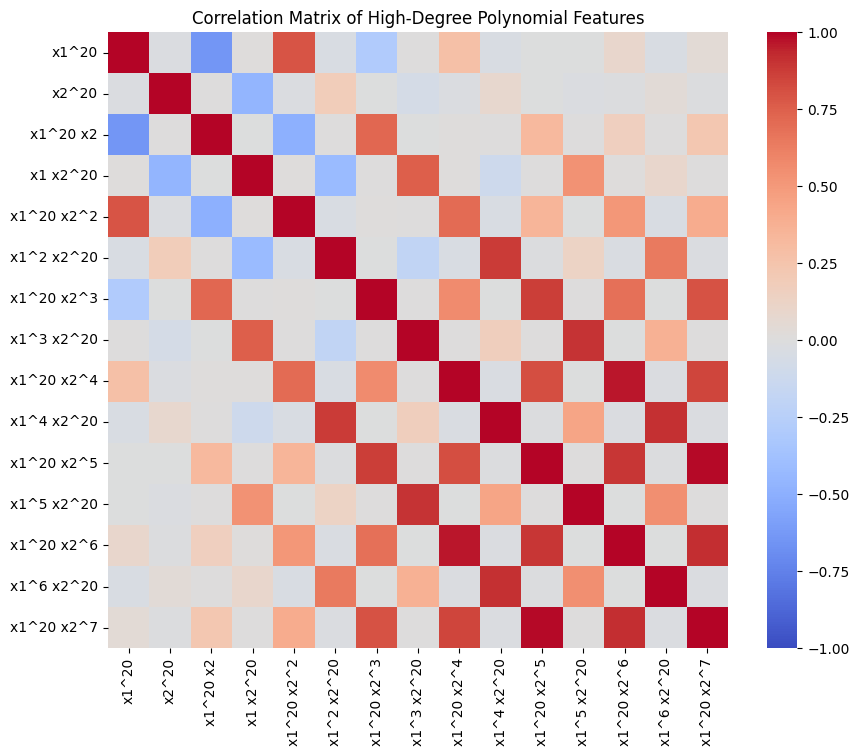

特徴量間の相関係数が非常に1（または-1）に近く、猛烈な多重共線性が発生していることがわかります。


In [15]:
# 20次〜30次の特徴量をいくつかサンプリングして相関行列を見る
high_degree_indices = [idx for idx, name in enumerate(poly.get_feature_names_out(['x1', 'x2']))
                       if 'x1^20' in name or 'x2^20' in name or 'x1^30' in name or 'x2^30' in name]
high_degree_indices = high_degree_indices[:15] # 可視化のため絞り込み

df_features = pd.DataFrame(X_train_poly_scaled[:, 1:][:, high_degree_indices],
                           columns=[poly.get_feature_names_out(['x1', 'x2'])[i] for i in high_degree_indices])

corr_matrix = df_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of High-Degree Polynomial Features")
plt.show()

print("特徴量間の相関係数が非常に1（または-1）に近く、猛烈な多重共線性が発生していることがわかります。")


---
## 6. 実験5：多重共線性と外挿領域での大暴走（Weight Tug-of-war）

多重共線性が高いとき、モデルは「内側と外側の分離」という難しいタスクを達成するため、**似たような特徴量に対して「一方は巨大なプラスの重み、もう一方は巨大なマイナスの重み」を割り当てて無理やりバランス（相殺）**させます。
学習データの範囲内では完璧に相殺されますが、未知の領域（例：`[1.5, 1.5]`）ではバランスが崩壊します。実際の重みの中身を見てみましょう。


In [16]:
# 反復50000回の学習済みモデル（先ほどの実験の最後の状態）の重みを解析
theta = model_es_scaled.theta_
bias = theta[0]
weights = theta[1:]

pt = np.array([[1.5, 1.5]])
pt_poly = poly.transform(pt)
pt_poly_scaled = scaler.transform(pt_poly)

contributions = pt_poly_scaled[0] * weights
indices = np.argsort(contributions)
feature_names = poly.get_feature_names_out(['x1', 'x2'])

print("【外挿領域 [1.5, 1.5] におけるLogitへの寄与トップ5】")
print("\n--- プラス方向に押し上げている特徴量（クラス1/オレンジへ） ---")
for i in range(1, 6):
    idx = indices[-i]
    print(f"{feature_names[idx]:10s}: 値(標準化後)={pt_poly_scaled[0, idx]:>12.2f}, 重み={weights[idx]:>6.2f} -> 寄与(積)={contributions[idx]:>14.2f}")

print("\n--- マイナス方向に押し下げている特徴量（クラス0/青へ） ---")
for i in range(5):
    idx = indices[i]
    print(f"{feature_names[idx]:10s}: 値(標準化後)={pt_poly_scaled[0, idx]:>12.2f}, 重み={weights[idx]:>6.2f} -> 寄与(積)={contributions[idx]:>14.2f}")

logit_15 = bias + np.sum(contributions)
print(f"\n最終的なLogitの合計値: {logit_15:,.2f} -> クラス1と自信満々に予測")


【外挿領域 [1.5, 1.5] におけるLogitへの寄与トップ5】

--- プラス方向に押し上げている特徴量（クラス1/オレンジへ） ---
x1^12 x2^18: 値(標準化後)=867136346.67, 重み=  0.17 -> 寄与(積)=  147724095.43
x1^14 x2^16: 値(標準化後)=867193051.81, 重み=  0.15 -> 寄与(積)=  127545621.29
x1^10 x2^20: 値(標準化後)=711088249.98, 重み=  0.18 -> 寄与(積)=  126585033.36
x1^16 x2^14: 値(標準化後)=736458520.63, 重み=  0.15 -> 寄与(積)=  112600927.70
x1^8 x2^22: 値(標準化後)=361040400.06, 重み=  0.19 -> 寄与(積)=   68734659.19

--- マイナス方向に押し下げている特徴量（クラス0/青へ） ---
x1^13 x2^17: 値(標準化後)=866823934.61, 重み= -0.04 -> 寄与(積)=  -34451595.44
x1^11 x2^19: 値(標準化後)=797066365.41, 重み= -0.03 -> 寄与(積)=  -24362433.73
x1^15 x2^15: 値(標準化後)=803845449.57, 重み= -0.02 -> 寄与(積)=  -16143200.92
x1^9 x2^21: 値(標準化後)=537407227.32, 重み= -0.03 -> 寄与(積)=  -15630386.01
x1^7 x2^23: 値(標準化後)=199231822.91, 重み= -0.02 -> 寄与(積)=   -3901449.09

最終的なLogitの合計値: 1,054,184,958.53 -> クラス1と自信満々に予測


**結論：外挿の大暴走**
外側の領域（例 `[1.5, 1.5]`）では、プラスに働く重み（偶数乗の交差項など）とマイナスに働く重み（奇数乗の交差項など）が、どちらも天文学的な値に膨れ上がります。
今回はたまたまプラス側の暴走スピードが勝ったため、数億レベルの巨大な正のLogitとなり、クラス1（オレンジ）と予測してしまったのです。
これが高次モデルにおける**外挿の危険性（ルンゲの現象）**であり、機械学習において正則化や早期終了がいかに必須であるかを示しています。
